In [ ]:
#========================================================================
# Name: plot_fig_1_3_4_5_S5_S6_cell_stats.ipynb
# Author: McKenna W. Stanford
# Author Contact: mckenna.stanford@pnnl.gov
#
# Description: Compute and plot cloud cell statistics for 3km WRF domain
#              including cloud-top temperature, reflectivity, and cloud counts.
#========================================================================

## Imports

In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
import matplotlib as mpl
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from sklearn.mixture import GaussianMixture
import pandas as pd
import os
import pickle
from pathlib import Path
from matplotlib.ticker import ScalarFormatter
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
plt.rcParams['text.usetex'] = True

/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


## Define data directories and load top-level datasets

In [2]:
# Configuration: data directory paths
wrf_cell_tracks_dir = '/pscratch/sd/m/mckenna/cacti/wrf/cell_tracking/'
save_path = '/global/homes/m/mckenna/figures/cacti/'

In [3]:
# Load datasets
all_stats = xr.open_dataset(
    os.path.join(wrf_cell_tracks_dir, 'cell_properties',
                 'cell_track_all_stats_20181015.0000_20190303.0000.nc')
)
updraft_stats = xr.open_dataset(
    os.path.join(wrf_cell_tracks_dir, 'cell_properties',
                 'cell_track_updraft_stats_20181015.0000_20190303.0000.nc')
)
track_stats = xr.open_dataset(
    os.path.join(wrf_cell_tracks_dir, 'stats',
                 'trackstats_20181015.0000_20190303.0000.nc')
)
track_numbers = xr.open_dataset(
    os.path.join(wrf_cell_tracks_dir, 'stats',
                 'tracknumbers_20181015.0000_20190303.0000.nc')
)

## Extract relevant variables, modify units, and put into dictionaries

In [4]:
# Extract mean microphysical variables
area = all_stats['Area'].values
mean_qt = all_stats['MeanQt'].values
mean_qc = all_stats['MeanQc'].values
mean_qs = all_stats['MeanQs'].values
mean_qg = all_stats['MeanQg'].values
mean_qi = all_stats['MeanQi'].values
mean_qr = all_stats['MeanQr'].values
mean_rho = all_stats['MeanRho'].values
mean_hd = all_stats['MeanHd'].values
mean_nwa = all_stats['MeanNwa'].values
mean_nc = all_stats['MeanNc'].values
mean_T = all_stats['MeanT'].values
mean_dbz = all_stats['MeanDBZ'].values
mean_qice = mean_qi + mean_qs + mean_qg  # Total ice content

# Calculate water and ice water contents (g/m^3)
mean_twc = mean_qt * mean_rho * 1.e3
mean_rwc = mean_qr * mean_rho * 1.e3
mean_clwc = mean_qc * mean_rho * 1.e3
mean_ciwc = mean_qi * mean_rho * 1.e3
mean_swc = mean_qs * mean_rho * 1.e3
mean_gwc = mean_qg * mean_rho * 1.e3
mean_lwc = mean_rwc + mean_clwc  # Total liquid water content
mean_iwc = mean_ciwc + mean_swc + mean_gwc  # Total ice water content

# Convert number concentrations to #/cc and temperature to Celsius
mean_nwa = mean_nwa * mean_rho * 1.e-6
mean_nc = mean_nc * mean_rho * 1.e-6
mean_T = mean_T - 273.15

# Extract max microphysical variables
max_qt = all_stats['MaxQt'].values
max_qc = all_stats['MaxQc'].values
max_qs = all_stats['MaxQs'].values
max_qg = all_stats['MaxQg'].values
max_qi = all_stats['MaxQi'].values
max_qr = all_stats['MaxQr'].values
max_hd = all_stats['MaxHd'].values
max_nwa = all_stats['MaxNwa'].values
max_nc = all_stats['MaxNc'].values
max_dbz = all_stats['MaxDBZ'].values
max_qice = max_qi + max_qs + max_qg

# Calculate max water and ice water contents
max_twc = max_qt * mean_rho * 1.e3
max_rwc = max_qr * mean_rho * 1.e3
max_clwc = max_qc * mean_rho * 1.e3
max_ciwc = max_qi * mean_rho * 1.e3
max_swc = max_qs * mean_rho * 1.e3
max_gwc = max_qg * mean_rho * 1.e3
max_lwc = max_rwc + max_clwc
max_iwc = max_ciwc + max_swc + max_gwc
max_nwa = max_nwa * mean_rho * 1.e-6
max_nc = max_nc * mean_rho * 1.e-6

# Extract track variables
maxETH_10dbz = track_stats['maxETH_10dbz'].values[:, :30]
mean_lat = track_stats['cell_meanlat'].values[:, :30]
mean_lon = track_stats['cell_meanlon'].values[:, :30]
base_time = track_stats['base_time'].values[:, :30]
tracks= track_stats['tracks'].values
end_merge_tracknumber = track_stats['end_merge_tracknumber'].values
start_split_tracknumber = track_stats['start_split_tracknumber'].values

mean_z = all_stats['MeanZ'].values

In [5]:
# Organize extracted variables into dictionaries
micro_dict = {
    'mean_twc': mean_twc, 'mean_lwc': mean_lwc, 'mean_clwc': mean_clwc,
    'mean_rwc': mean_rwc, 'mean_iwc': mean_iwc, 'mean_ciwc': mean_ciwc,
    'mean_gwc': mean_gwc, 'mean_swc': mean_swc, 'mean_nwa': mean_nwa,
    'mean_nc': mean_nc, 'mean_dbz': mean_dbz, 'max_twc': max_twc,
    'max_lwc': max_lwc, 'max_clwc': max_clwc, 'max_rwc': max_rwc,
    'max_iwc': max_iwc, 'max_ciwc': max_ciwc, 'max_swc': max_swc,
    'max_gwc': max_gwc, 'max_nwa': max_nwa, 'max_nc': max_nc,
    'max_dbz': max_dbz, 'mean_qt': mean_qt, 'max_qt': max_qt,
    'mean_qc': mean_qc, 'max_qc': max_qc, 'mean_qs': mean_qs,
    'max_qs': max_qs, 'mean_qi': mean_qi, 'max_qi': max_qi,
    'mean_qg': mean_qg, 'max_qg': max_qg, 'mean_qr': mean_qr,
    'max_qr': max_qr, 'mean_qice': mean_qice, 'max_qice': max_qice,
    'mean_z': mean_z
}

thermo_dict = {
    'mean_T': mean_T,
    'mean_z': mean_z
}

track_dict = {
    'mean_lat': mean_lat,
    'mean_lon': mean_lon,
    'base_time': base_time,
    'tracks': tracks,
    'end_merge_tracknumber': end_merge_tracknumber,
    'start_split_tracknumber': start_split_tracknumber,
    'maxETH_10dbz': maxETH_10dbz
}

## Print Dataset Statistics
Get the dimensions of each dataset to verify correct loading.

In [6]:
# Get dataset dimensions
num_tracks = len(track_stats.coords['tracks'].values)
nt = len(track_stats.coords['times'].values)

print("Dataset Summary:")
print(f"  updraft_stats: {len(updraft_stats.coords['tracks'].values)} tracks × "
      f"{len(updraft_stats.coords['times'].values)} times")
print(f"  all_stats: {len(all_stats.coords['tracks'].values)} tracks × "
      f"{len(all_stats.coords['times'].values)} times")
print(f"  track_stats: {num_tracks} tracks × {nt} times")

Dataset Summary:
  updraft_stats: 47230 tracks × 30 times
  all_stats: 47230 tracks × 30 times
  track_stats: 47230 tracks × 150 times


In [7]:
print('Initial number of cells:',num_tracks)

Initial number of cells: 47230


## Filter Cells by Geographic Domain
Remove cells west of 64.9°W (terrain blockage)

In [8]:
print('Shape of micro vars:',np.shape(micro_dict['mean_z']))
print('Shape of thermo vars:',np.shape(thermo_dict['mean_T']))
print('Shape of lat/lon:',np.shape(track_dict['mean_lon']))

Shape of micro vars: (47230, 30, 80)
Shape of thermo vars: (47230, 30, 80)
Shape of lat/lon: (47230, 30)


In [9]:
# For each row (axis=1), find the minimum longitude, ignoring any NaNs.
min_lons_per_record = np.nanmin(track_dict['mean_lon'], axis=1)
# The shape will be (47230,)
print(f"Shape of min_lons_per_record: {min_lons_per_record.shape}")
# Now, our final mask is a simple 1D comparison.
final_mask = min_lons_per_record >= -64.9
print(f"Kept {np.sum(final_mask)} records out of {track_dict['mean_lon'].shape[0]}")
print('% of cells removed:',(1. - np.sum(final_mask)/track_dict['mean_lon'].shape[0])*100.)

Shape of min_lons_per_record: (47230,)
Kept 29719 records out of 47230
% of cells removed: 37.0760110099513


In [10]:
# Create new dictionaries to hold the filtered data
filtered_micro_dict = {}
filtered_thermo_dict = {}
filtered_track_dict = {}

# Filter the track_dict
print("\nFiltering track_dict...")
for key, value in track_dict.items():
    original_shape = value.shape
    # Apply the mask to the first dimension
    filtered_track_dict[key] = value[final_mask]
    print(f"  Variable '{key}': {original_shape} -> {filtered_track_dict[key].shape}")

# Filter the micro_dict
print("\nFiltering micro_dict...")
for key, value in micro_dict.items():
    original_shape = value.shape
    # Apply the same mask to the first dimension
    filtered_micro_dict[key] = value[final_mask]
    print(f"  Variable '{key}': {original_shape} -> {filtered_micro_dict[key].shape}")

# Filter the thermo_dict
print("\nFiltering thermo_dict...")
for key, value in thermo_dict.items():
    original_shape = value.shape
    # Apply the same mask to the first dimension
    filtered_thermo_dict[key] = value[final_mask]
    print(f"  Variable '{key}': {original_shape} -> {filtered_thermo_dict[key].shape}")


Filtering track_dict...
  Variable 'mean_lat': (47230, 30) -> (29719, 30)
  Variable 'mean_lon': (47230, 30) -> (29719, 30)
  Variable 'base_time': (47230, 30) -> (29719, 30)
  Variable 'tracks': (47230,) -> (29719,)
  Variable 'end_merge_tracknumber': (47230,) -> (29719,)
  Variable 'start_split_tracknumber': (47230,) -> (29719,)
  Variable 'maxETH_10dbz': (47230, 30) -> (29719, 30)

Filtering micro_dict...
  Variable 'mean_twc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_lwc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_clwc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_rwc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_iwc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_ciwc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_gwc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_swc': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_nwa': (47230, 30, 80) -> (29719, 30, 80)
  Variable 'mean_nc': (47230, 30, 80) -> (29719, 30, 80)
  Vari

In [11]:
# Reassign filtered dictionaries back to original dictionary names for downstream code
micro_dict = filtered_micro_dict
thermo_dict = filtered_thermo_dict
track_dict = filtered_track_dict

In [12]:
for key,val in track_dict.items():
    print(key,np.shape(val))

for key,val in micro_dict.items():
    print(key,np.shape(val))

mean_lat (29719, 30)
mean_lon (29719, 30)
base_time (29719, 30)
tracks (29719,)
end_merge_tracknumber (29719,)
start_split_tracknumber (29719,)
maxETH_10dbz (29719, 30)
mean_twc (29719, 30, 80)
mean_lwc (29719, 30, 80)
mean_clwc (29719, 30, 80)
mean_rwc (29719, 30, 80)
mean_iwc (29719, 30, 80)
mean_ciwc (29719, 30, 80)
mean_gwc (29719, 30, 80)
mean_swc (29719, 30, 80)
mean_nwa (29719, 30, 80)
mean_nc (29719, 30, 80)
mean_dbz (29719, 30, 80)
max_twc (29719, 30, 80)
max_lwc (29719, 30, 80)
max_clwc (29719, 30, 80)
max_rwc (29719, 30, 80)
max_iwc (29719, 30, 80)
max_ciwc (29719, 30, 80)
max_swc (29719, 30, 80)
max_gwc (29719, 30, 80)
max_nwa (29719, 30, 80)
max_nc (29719, 30, 80)
max_dbz (29719, 30, 80)
mean_qt (29719, 30, 80)
max_qt (29719, 30, 80)
mean_qc (29719, 30, 80)
max_qc (29719, 30, 80)
mean_qs (29719, 30, 80)
max_qs (29719, 30, 80)
mean_qi (29719, 30, 80)
max_qi (29719, 30, 80)
mean_qg (29719, 30, 80)
max_qg (29719, 30, 80)
mean_qr (29719, 30, 80)
max_qr (29719, 30, 80)
mean_qic

## Filter cells with that start as splits
Remove cells that start as splits from parent cells

In [13]:
# Identify cells with no splitting or merging
nonmerge_id = np.where(np.isnan(track_dict['end_merge_tracknumber']))[0]
nonsplit_id = np.where(np.isnan(track_dict['start_split_tracknumber']))[0]
nonsplitmerge_id = np.where(
    (np.isnan(track_dict['start_split_tracknumber'])) 
    & (np.isnan(track_dict['end_merge_tracknumber']))
)[0]

print("Split/Merge Statistics:")
print(f"  Non-mergers: {len(nonmerge_id)/len(track_dict['end_merge_tracknumber'])*100:.1f}%")
print(f"  Non-splitters: {len(nonsplit_id)/len(track_dict['start_split_tracknumber'])*100:.1f}%")
print(f"  Neither split nor merge: "
      f"{len(nonsplitmerge_id)/len(track_dict['start_split_tracknumber'])*100:.1f}%")
print(f"  Removed due to splitting: "
      f"{(1. - len(nonsplit_id)/len(track_dict['start_split_tracknumber']))*100:.1f}%")

Split/Merge Statistics:
  Non-mergers: 81.7%
  Non-splitters: 79.1%
  Neither split nor merge: 69.6%
  Removed due to splitting: 20.9%


In [14]:
# Actually remove split cells here

for key, val in micro_dict.items():
    micro_dict[key] = val[nonsplit_id, :, :]

for key, val in thermo_dict.items():
    thermo_dict[key] = val[nonsplit_id, :, :]

for key, val in track_dict.items():
    # Handle based on array dimensionality
    if val.ndim == 1:
        track_dict[key] = val[nonsplit_id]
    elif val.ndim == 2:
        track_dict[key] = val[nonsplit_id, :]
    else:
        # If there are higher dimensional arrays, handle accordingly
        track_dict[key] = val[nonsplit_id]

mean_z = np.nanmean(micro_dict['mean_z'][:, 0, :].squeeze(), axis=0)

In [15]:
# Print dimensions of new filtered datasets
for key,val in micro_dict.items():
    print(key,np.shape(val))
for key,val in thermo_dict.items():
    print(key,np.shape(val))
for key,val in track_dict.items():
    print(key,np.shape(val))
print(np.shape(mean_z))

mean_twc (23511, 30, 80)
mean_lwc (23511, 30, 80)
mean_clwc (23511, 30, 80)
mean_rwc (23511, 30, 80)
mean_iwc (23511, 30, 80)
mean_ciwc (23511, 30, 80)
mean_gwc (23511, 30, 80)
mean_swc (23511, 30, 80)
mean_nwa (23511, 30, 80)
mean_nc (23511, 30, 80)
mean_dbz (23511, 30, 80)
max_twc (23511, 30, 80)
max_lwc (23511, 30, 80)
max_clwc (23511, 30, 80)
max_rwc (23511, 30, 80)
max_iwc (23511, 30, 80)
max_ciwc (23511, 30, 80)
max_swc (23511, 30, 80)
max_gwc (23511, 30, 80)
max_nwa (23511, 30, 80)
max_nc (23511, 30, 80)
max_dbz (23511, 30, 80)
mean_qt (23511, 30, 80)
max_qt (23511, 30, 80)
mean_qc (23511, 30, 80)
max_qc (23511, 30, 80)
mean_qs (23511, 30, 80)
max_qs (23511, 30, 80)
mean_qi (23511, 30, 80)
max_qi (23511, 30, 80)
mean_qg (23511, 30, 80)
max_qg (23511, 30, 80)
mean_qr (23511, 30, 80)
max_qr (23511, 30, 80)
mean_qice (23511, 30, 80)
max_qice (23511, 30, 80)
mean_z (23511, 30, 80)
mean_T (23511, 30, 80)
mean_z (23511, 30, 80)
mean_lat (23511, 30)
mean_lon (23511, 30)
base_time (2351

In [16]:
micro_dict_init_all_cells = micro_dict.copy()
for key,val in micro_dict_init_all_cells.items():
    micro_dict_init_all_cells[key] = val[:,0,:]

thermo_dict_init_all_cells = thermo_dict.copy()
for key,val in thermo_dict_init_all_cells.items():
    thermo_dict_init_all_cells[key] = val[:,0,:]

track_dict_init_all_cells = track_dict.copy()
for key,val in track_dict_init_all_cells.items():
    if 'track' not in key:
        track_dict_init_all_cells[key] = val[:,0]

In [19]:
# Column maximum IWC for each cell
max_iwc_col = np.nanmax(micro_dict_init_all_cells['max_iwc'], axis=1)

# Ice boolean
has_ice = max_iwc_col > 1.e-6  

print(f"Total filtered cells: {len(has_ice)}")
print(f"Cells with ice at initiation: {np.sum(has_ice)} ({np.sum(has_ice)/len(has_ice)*100:.1f}%)")
print(f"Cells without ice at initiation: {np.sum(~has_ice)} ({np.sum(~has_ice)/len(has_ice)*100:.1f}%)")

Total filtered cells: 23511
Cells with ice at initiation: 15105 (64.2%)
Cells without ice at initiation: 8406 (35.8%)


## Define functions used to calculate cloud boundaries

### How Cloud Boundaries Are Calculated:

**Overall Approach:**
Cloud boundaries are calculated by identifying vertically contiguous layers of condensate (regions where mixing ratio exceeds a threshold). The key insight is that **clouds may have multiple vertically-separated layers**, and each layer's depth is calculated independently.

**Gap Handling (Vertical Continuity):**
The algorithm uses a `gap` parameter to define what constitutes a "break" in vertical continuity:
- If two condensate-containing levels are separated by more than `gap` grid points (with no condensate between them), they are treated as **separate cloud layers**
- The gap represents dry air (or air below the condensate threshold) between cloud layers
- This is essential because cells often have:
  - A **cloud layer at the base** (liquid water cloud)
  - **Clear air in the middle** (above the freezing level, or in an inversion)
  - A **layer of ice aloft** (anvil ice)
  
**Example:**
If a profile has condensate at levels [0, 1, 2, **10, 11, 12**] with `gap=3`:
- Levels 0-2 form **Layer 1** (the "main" cloud)
- Levels 10-12 form **Layer 2** (the "anvil" above the gap)
- Even though both have condensate, they're separate because the gap between level 2 and 10 exceeds 3 grid points

**Validation of Vertical Contiguity:**
For your use case with condensate threshold-based cloud identification:
- ✓ Correctly treats continuous condensate as a single layer
- ✓ Properly separates vertically-disjoint condensate layers
- ✓ Calculates thickness as the vertical distance between the lowest and highest condensate indices in each layer
- ✓ Correctly handles multiple cloud layers in a single profile

**Current Settings:**
- `gap = 2`: Cloud layers separated by > 2 grid points are treated as distinct layers
- `min_thick = 0`: All layers are retained (no minimum thickness requirement)

In [16]:
def calc_cloud_boundary(height, temp, idxcld, gap, min_thick):
    """
    Calculates cloud base, cloud top height and thickness for vertically contiguous condensate layers.
    
    This function takes a list of height indices where condensate exists (above a threshold)
    and identifies separate cloud layers by detecting gaps in the vertical profile. Each
    gap larger than the specified threshold indicates a separate cloud layer (e.g., separated
    by clear air or by being above and below a melting level).
    
    ----------
    height: np.array(float)
        Absolute height array (1D), in meters. Height increases upward (e.g., [100, 200, 300, ...]).
    temp: np.array(float)
        Temperature array (1D), in degrees C. Must be same length as height.
    idxcld: np.array(int)
        Array of height indices (integer indices into height and temp arrays) where condensate 
        exceeds the threshold. These indices define which vertical levels contain cloud.
        Example: if idxcld = [0, 1, 2, 10, 11, 12], there are two groups of condensate levels.
    gap: int or None
        **CRITICAL PARAMETER**: Vertical gap threshold in grid points (number of levels).
        If consecutive elements in idxcld differ by MORE than `gap`, they belong to different layers.
        Example: gap=2 means if idxcld[i+1] - idxcld[i] > 2, a new layer starts.
        Set to None to disable gap detection entirely — all condensate is treated as one layer.
    min_thick: float
        Minimum required thickness (in height units, meters) for a layer to be retained.
        Currently NOT ENFORCED in the code (layers below min_thick are still included).

    Returns
    ----------
    cloud_base: np.ndarray(nLayers)
        Cloud-base height (lowest height) for each cloud layer [meters].
    cloud_top: np.ndarray(nLayers)
        Cloud-top height (highest height) for each cloud layer [meters].
    cloud_base_temp: np.ndarray(nLayers)
        Temperature at cloud base [deg C].
    cloud_top_temp: np.ndarray(nLayers)
        Temperature at cloud top [deg C].
    cloud_thick: np.ndarray(nLayers)
        Thickness of each cloud layer = cloud_top - cloud_base [meters].
        This is the VERTICAL EXTENT of condensate in that layer.
    layer_gap: np.ndarray(nLayers-1)
        Gap between successive cloud layers = cloud_base[i+1] - cloud_top[i] [meters].
        Positive values (gaps in height). Used to verify that layers are indeed separated.
    """

    # ===== STEP 1: Identify separate cloud layers by detecting gaps =====
    # If gap is None, skip gap detection and treat all condensate as one layer.
    # Otherwise, find where consecutive indices in idxcld have gaps larger than 'gap' parameter.
    
    if gap is None:
        # No gap accounting: treat all condensate as a single layer
        Layers = [idxcld]
    else:
        # np.diff(idxcld) = difference between consecutive indices
        # np.where(np.diff(idxcld) > gap) finds indices where the gap exceeds the threshold
        # These locations are split points that separate layers.
        
        # Example: idxcld = [0, 1, 2, 10, 11, 12] with gap=2
        #   np.diff(idxcld) = [1, 1, 8, 1, 1]
        #   np.where(diff > 2) = [2] (the gap of 8 between indices 2 and 10)
        #   Split locations = [3] (np.where result [2] + 1)
        #   Layers = [[0,1,2], [10,11,12]]
        
        Layers = np.split(idxcld, np.where(np.diff(idxcld) > gap)[0]+1)
    nLayers = len(Layers)
            

    # ===== STEP 2: Initialize output arrays =====
    # Create arrays to store results for all layers
    cloud_base = np.zeros(nLayers, dtype=np.float32)
    cloud_base_temp = np.zeros(nLayers, dtype=np.float32)
    cloud_top = np.zeros(nLayers, dtype=np.float32)
    cloud_top_temp = np.zeros(nLayers, dtype=np.float32)
    cloud_thick = np.zeros(nLayers, dtype=np.float32)
    layer_gap = np.zeros(nLayers-1, dtype=np.float32)

    if nLayers > 0:
        # ===== STEP 3: Process each cloud layer =====
        # Loop over each identified layer and calculate its boundaries
        
        for iLayer in range(0, nLayers):
            # For this layer, get the LOWEST condensate level (smallest index = lowest height)
            # and the HIGHEST condensate level (largest index = highest height)
            
            # Lowest condensate index in this layer: Layers[iLayer][0]
            # Highest condensate index in this layer: Layers[iLayer][-1]
            
            zb = height[Layers[iLayer][0]]      # Base height (lowest)
            zt = height[Layers[iLayer][-1]]     # Top height (highest)
            tb = temp[Layers[iLayer][0]]        # Temperature at base
            tt = temp[Layers[iLayer][-1]]       # Temperature at top
            
            # Calculate layer thickness as vertical distance
            dz = zt - zb  # THICKNESS = TOP HEIGHT - BASE HEIGHT
            
            # Store results for this layer
            # NOTE: These represent the BOUNDARIES of the continuous condensate layer
            # They span from the LOWEST to the HIGHEST condensate-containing level in that layer
            cloud_base[iLayer] = zb
            cloud_base_temp[iLayer] = tb
            cloud_top[iLayer] = zt
            cloud_top_temp[iLayer] = tt
            cloud_thick[iLayer] = dz
            
        # ===== STEP 4: Calculate gaps between layers =====
        # For each pair of successive layers, calculate the gap (clear air between them)
        
        if nLayers > 1:
            for iLayer in range(0, nLayers-1):
                # Gap = (base of next layer) - (top of current layer)
                # This should be positive if layers are properly separated
                layer_gap[iLayer] = cloud_base[iLayer+1] - cloud_top[iLayer]
            
    return cloud_base, cloud_top, cloud_base_temp, cloud_top_temp, cloud_thick, layer_gap


### Summary: Cloud Depth Calculation Validation

✓ **Does this correctly calculate cell cloud depth as a vertically contiguous condensate layer?**

**YES, with the following qualifications:**

1. **For single-layer clouds** (most common): Cloud thickness = (height of topmost condensate) - (height of bottommost condensate)
   - This correctly captures the full vertical extent of the contiguous condensate region

2. **For multi-layer clouds** (e.g., separated by a dry layer or melting level): 
   - Each layer's thickness is calculated independently
   - You'll get multiple thickness values, one per layer
   - You need to decide which to use:
     - Use the **bottommost layer** (cloud_thick[0]) for the main cumulus cloud depth
     - Use the **topmost layer** (cloud_thick[-1]) for anvil thickness
     - Use the **sum** if you want total column condensate depth
     - Currently in your code (line ~1530), you use **cb_qc[0]** which gets the bottommost layer

3. **Gap handling ensures physical validity:**
   - Layers separated by gaps ≥ 3 grid points (with current `gap=2`) won't be mistakenly merged
   - This prevents the algorithm from incorrectly connecting:
     - Cloud base (at condensation level) to anvil ice (at upper troposphere)
     - as if they were a single layer

4. **Assumptions made:**
   - Cloud base = height of FIRST (lowest) condensate-containing level
   - Cloud top = height of LAST (highest) condensate-containing level  
   - Thickness = direct vertical distance (doesn't account for layering within each continuous region)


In [17]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on Earth using the Haversine formula.
    
    Parameters:
    -----------
    lat1, lon1: float or np.array
        Latitude and longitude of first point(s) in degrees
    lat2, lon2: float or np.array
        Latitude and longitude of second point(s) in degrees
    
    Returns:
    --------
    distance: float or np.array
        Distance in kilometers
    """
    # Earth's radius in kilometers
    R = 6371.0
    
    # Convert degrees to radians
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    
    # Differences
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    # Haversine formula
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c


def identify_isolated_cells(cell_lats, cell_lons, cell_times=None, radius_km=20.0, time_window_seconds=21600):
    """
    Identify cells that have fewer than 1 other cell within a specified radius at similar initialization time.
    This function considers only cells at initialization (1D arrays).
    
    Parameters:
    -----------
    cell_lats: np.array(float)
        1D array of cell latitudes at initialization time step
    cell_lons: np.array(float)
        1D array of cell longitudes at initialization time step
    cell_times: np.array(datetime64) or None
        1D array of cell initialization times (datetime64). If provided, only cells within time_window are counted
    radius_km: float
        Search radius in kilometers (default: 20 km)
    time_window_seconds: float
        Time window in seconds for considering cells with similar initialization time (default: 21600 = 6 hours)
    
    Returns:
    --------
    isolation_mask: np.array(bool)
        Boolean mask where True indicates cells with < 1 other cell within radius and time window
    neighbor_counts: np.array(int)
        Number of other cells within radius and time window for each cell
    """
    n_cells = len(cell_lats)
    neighbor_counts = np.zeros(n_cells, dtype=int)
    
    # For each cell, count how many other cells are within the radius and time window
    for i in range(n_cells):
        # If times provided, filter by time window first
        if cell_times is not None:
            # Convert to timedelta (in nanoseconds), then to seconds for comparison
            time_diffs = np.abs(cell_times - cell_times[i])
            time_mask = (time_diffs / np.timedelta64(1, 's')) <= time_window_seconds
        else:
            time_mask = np.ones(n_cells, dtype=bool)
        
        # Calculate distances from cell i to all other cells
        distances = haversine_distance(
            cell_lats[i], cell_lons[i],
            cell_lats, cell_lons
        )
        
        # Count neighbors within radius AND time window (excluding self, distance = 0)
        neighbors_in_radius = np.sum((distances <= radius_km) & (distances > 0) & time_mask)
        neighbor_counts[i] = neighbors_in_radius
    
    # Create mask for isolated cells (with 0 other cells within radius and time window)
    isolation_mask = neighbor_counts < 1
    
    return isolation_mask, neighbor_counts


In [18]:
def cloud_macro_wrf(var2d, height2d, temp2d, num_tracks, thresh, gap, min_thick, max_num_layers):
    """
    Calculates layer base and top height, layer thickness, and gap thickness between layers for all cells at initiation time step.
    ----------
    var2d: np.DataArray(float)
        2D condensate array (NumPy Array), assumes in [x,z] order where x is track number and z is height.
    height2d: np.array(float)
        height array (2D), assumes in the same order as var2d [x,z] order.
    temp2d: np.array(float)
        temperature array (2D), assumes in the same order as var2d [x,z] order.
    num_tracks: int
        Number of tracks.
    thresh: float
        Condensate threshold to calculate cloud-top height.
    gap: int
        If a gap larger than this exists, condensate is separated into different layers.
        In integer units, meaning number of layers between gaps rather than a physical height difference threshold
    min_thick: float
        Minimum thickness of a condensate layer.
    max_num_layers: int
        Maximum number of layers to consider.

    Returns
    ----------
    macro_dict: dictionary
        keys:
            cth: np.ndarray((num_tracks,num_layers)) cloud top height (m)
            cbh: np.ndarray((num_tracks,num_layers)) cloud base height (m)
            ctt: np.ndarray((num_tracks,num_layers)) cloud top temperature (deg C)
            cbt: np.ndarray((num_tracks,num_layers)) cloud base temperature (deg C)
            c_thick: np.ndarray((num_tracks,num_layers)) cloud layer thickness (m)
            num_layers: np.ndarray(num_tracks) number of cloud layers in cell profile
            layer_gap: np.ndarray((num_tracks,num_layers-1)) gap between layers for cells with more than one layer (m)
    """
    shape1d = len(var2d[:,0])

    # Define binary cloud mask using condensate threshold
    cloudmask = var2d > thresh

    # Find 1D locations with clouds anywhere in the column
    # Then get indices of those cloudy points
    xidx = np.where(np.max(cloudmask,axis=1) == 1)[0]

    # Total number of points with clouds
    npix_cloud = len(xidx)
    
    cth = np.full((shape1d,max_num_layers), np.nan, dtype=np.float32)
    ctt = np.full((shape1d,max_num_layers), np.nan, dtype=np.float32)
    cbh = np.full((shape1d,max_num_layers), np.nan, dtype=np.float32)
    cbt = np.full((shape1d,max_num_layers), np.nan, dtype=np.float32)
    c_thick = np.full((shape1d,max_num_layers), np.nan, dtype=np.float32)
    num_layers = np.full(shape1d, np.nan, dtype=np.float32)
    layer_gaps = np.full((shape1d,max_num_layers-1), np.nan, dtype=np.float32)

    # Loop over each point with clouds
    for il in range(0, npix_cloud):
        # Get the profile at location x
        idxcld = np.array(np.where(np.squeeze(cloudmask[xidx[il],:]) == 1)[0])
        iheight = height2d[xidx[il],:]
        itemp = temp2d[xidx[il],:]

        # Check if there is any clouds defined
        if len(idxcld) > 0:
            # Call calc_cloud_boundary to get cloud_base, cloud_top height
            cb, ct, tb, tt, dz, layer_gap = calc_cloud_boundary(iheight, itemp, idxcld, gap, min_thick)
            tmp_num_layers = np.size(cb)
            num_layers[xidx[il]] = tmp_num_layers

            thin_id = np.where(dz == 0.)
            if np.size(thin_id) > 0.:
                thick_enough_id = np.where(dz > 0.)
                if np.size(thick_enough_id) > 1.:
                    thick_enough_id = thick_enough_id[0]
                ct = ct[thick_enough_id]
                cb = cb[thick_enough_id]
                dz = dz[thick_enough_id]
                tt = tt[thick_enough_id]
                tb = tb[thick_enough_id]
                
            tmp_num_layers = np.size(cb)
            num_layers[xidx[il]] = tmp_num_layers
            
            for kk in range(tmp_num_layers):
                cth[xidx[il],kk] = ct[kk]
                cbh[xidx[il],kk] = cb[kk]
                c_thick[xidx[il],kk] = dz[kk]
                ctt[xidx[il],kk] = tt[kk]
                cbt[xidx[il],kk] = tb[kk]

            if tmp_num_layers > 1.:
                for kk in range(tmp_num_layers-1):
                    layer_gaps[xidx[il],kk] = layer_gap[kk]

    macro_dict = {'cth':cth,\
                  'cbh':cbh,\
                  'ctt':ctt,\
                  'cbt':cbt,\
                  'c_thick':c_thick,\
                  'num_layers':num_layers,\
                  'layer_gaps':layer_gaps,\
                 }
                    
    return macro_dict

## Calculate Cloud Layer Macro Characteristics
Determine cloud-top height, cloud-base height, thickness, and layer gaps at initialization

In [19]:
# Parameters for cloud macro characteristics calculation
var2d = micro_dict['max_qt'][:, 0, :].squeeze()
aero2d = micro_dict['mean_nwa'][:, 0, :].squeeze()
height2d = micro_dict['mean_z'][:, 0].squeeze()
temp2d = thermo_dict['mean_T'][:, 0].squeeze()
std = True
# Configuration
if std:
    thresh = 1.e-12  # Condensate threshold (kg/kg); Used for all main-manuscript analyses
else:    
    thresh = 1.e-6  # Condensate threshold (kg/kg); Stricter threshold used for sensitivity test to produce Fig. S6

gap = 2  # Grid points between gaps to define separate layers (set to None to ignore gaps entirely)
max_num_layers = 5
min_thick = 250.  # Minimum layer thickness (m)

print("Cloud Macro Parameters:")
print(f"  Condensate threshold: {thresh:.2e} kg/kg")
print(f"  Gap criterion: {gap} grid points")
print(f"  Max layers: {max_num_layers}")
print(f"  Shape of var2d: {np.shape(var2d)}")
print(f"  Shape of height2d: {np.shape(height2d)}")
print(f"  Shape of temp2d: {np.shape(temp2d)}")

# Calculate macro characteristics
macro_dict = cloud_macro_wrf(var2d, height2d, temp2d, num_tracks, thresh, gap, min_thick, max_num_layers)


Cloud Macro Parameters:
  Condensate threshold: 1.00e-12 kg/kg
  Gap criterion: 2 grid points
  Max layers: 5
  Shape of var2d: (23511, 80)
  Shape of height2d: (23511, 80)
  Shape of temp2d: (23511, 80)


In [20]:
for key,val in macro_dict.items():
    print(key,np.shape(val),np.nanmax(val),np.nanmin(val))

cth (23511, 5) 20559.322 525.98645
cbh (23511, 5) 19065.02 253.96835
ctt (23511, 5) 28.236084 -82.12019
cbt (23511, 5) 37.001007 -79.27402
c_thick (23511, 5) 20173.309 97.97888
num_layers (23511,) 4.0 1.0
layer_gaps (23511, 4) 10735.771 306.25854


## Analyze Layer Distribution
Count the number of cells with each number of cloud layers

In [21]:
# Calculate percentage of cells with each number of layers
print("Cloud Layer Distribution:")
for ii in range(max_num_layers):
    num_layers_id = np.where(macro_dict['num_layers'] == ii + 1)[0]
    pct = np.size(num_layers_id) / np.size(macro_dict['num_layers']) * 100.0
    print(f"  {ii+1} layer(s): {pct:.1f}%")

Cloud Layer Distribution:
  1 layer(s): 79.6%
  2 layer(s): 18.8%
  3 layer(s): 1.5%
  4 layer(s): 0.1%
  5 layer(s): 0.0%


## Plot map of locations for cell initiation
Open and check terrain file

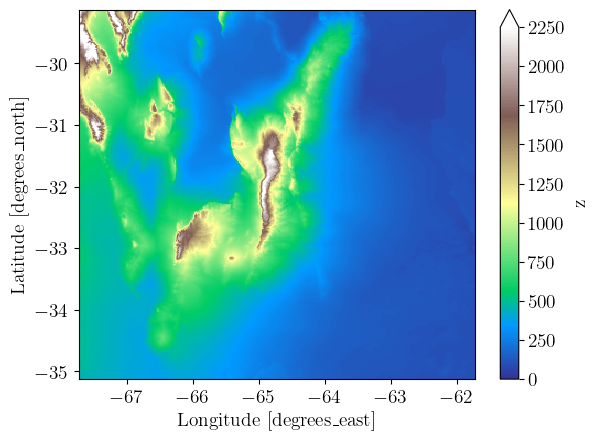

In [224]:
terrain_file = f'/pscratch/sd/m/mckenna/cacti/topo_cacti_csapr2_large.nc'
terr = xr.open_dataset(terrain_file)
topoZ = terr['z']
topoLon = terr['x']
topoLat = terr['y']
topoZ.plot(vmin=0, vmax=2250, cmap='terrain')
radar_lat = -32.1264
radar_lon = -64.7284

In [225]:
minlon, maxlon = -65.4, -63.5
minlat, maxlat = -33.1, -31.1
buffer = 0.1
lonbins = np.arange(minlon-buffer, maxlon+buffer, 0.1)
latbins = np.arange(minlat-buffer, maxlat+buffer, 0.1)
bins = [lonbins, latbins]

In [226]:
import warnings
warnings.filterwarnings(
    'ignore',
    message='Approximating coordinate system',
    category=UserWarning,
    module='cartopy'
)

/tmp/ipykernel_2186390/2339403908.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


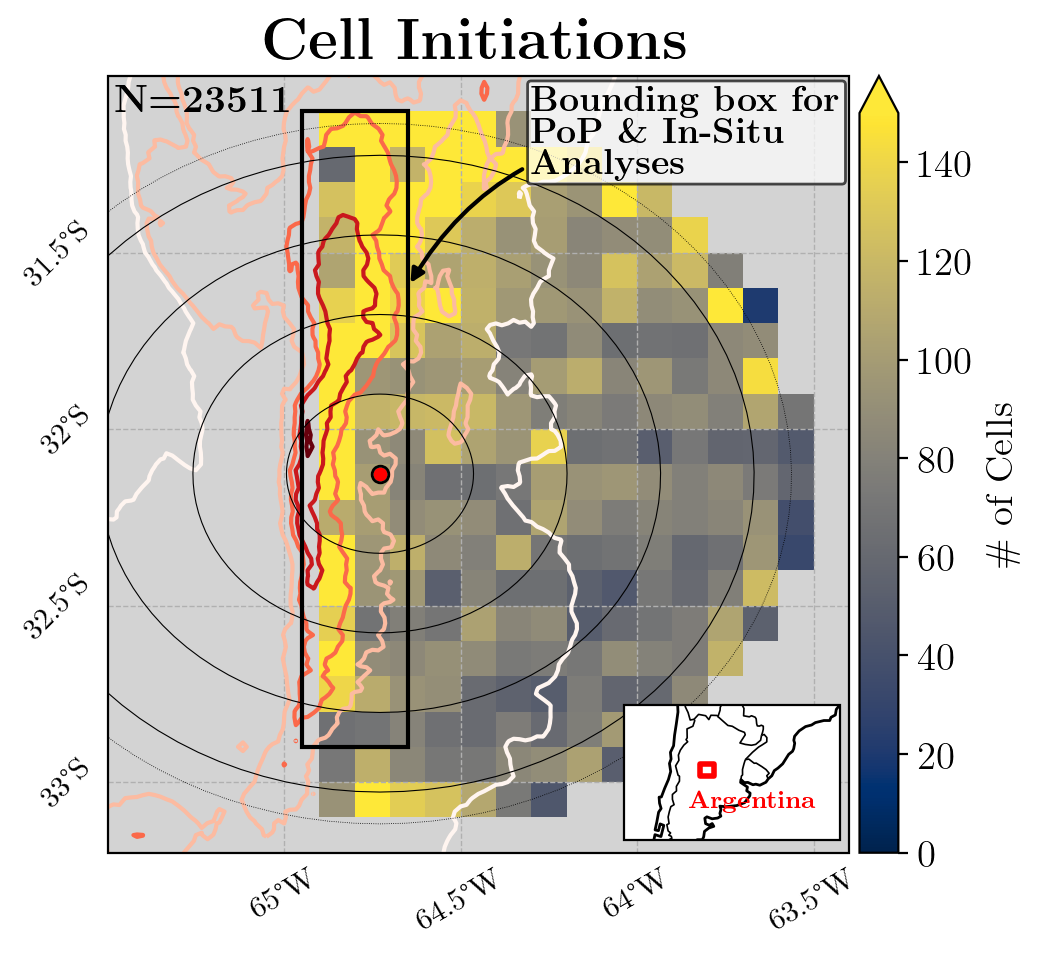

In [227]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import matplotlib.patches as mpatches

# ── rc params ────────────────────────────────────────────────────────────────
mpl.rcParams['font.size']   = 14
mpl.rcParams['font.family'] = 'DejaVu Sans'

# ── constants ─────────────────────────────────────────────────────────────────
Fontsize    = 14
resolution  = '110m'
cmap_topo   = 'Reds'
topo_levs   = [500, 1000, 1500, 2000, 2500]
radii       = np.arange(25, 101, 25)          # range rings [km]
azimuths    = np.arange(0, 361, 30)           # HSRHI azimuth angles [deg]

# ── locations ─────────────────────────────────────────────────────────────────
radar_lon, radar_lat = -64.7284, -32.1264     # CSAPR radar
cor_lon,   cor_lat   = -64.183333, -31.416667  # Córdoba city

# ── bounding box ──────────────────────────────────────────────────────────────
bbox_lonmin = -64.95
bbox_lonmax = -64.65
bbox_latmin = -32.9
bbox_latmax = -31.1

# ── map extent / projection ───────────────────────────────────────────────────
lonmin, lonmax = -66, -63.5
latmin, latmax = -33.15, -31.1
map_extent = [lonmin, lonmax, latmin, latmax]
proj       = ccrs.PlateCarree()

# ── gridline locators ─────────────────────────────────────────────────────────
lonvals = mpl.ticker.FixedLocator(np.arange(-70, -60.1, 0.5))
latvals = mpl.ticker.FixedLocator(np.arange(-40, -30.1, 0.5))

# ── natural earth features ────────────────────────────────────────────────────
land    = cfeature.NaturalEarthFeature('physical', 'land',    resolution)
ocean   = cfeature.NaturalEarthFeature('physical', 'ocean',   resolution)
borders = cfeature.NaturalEarthFeature(
              'cultural', 'admin_0_boundary_lines_land', resolution)

# ── figure ────────────────────────────────────────────────────────────────────
# dpi=200 was making the figure render very large on screen;
# use ~100 for normal display and increase only for saving.
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5), dpi=200,           # <── reduced dpi fixes "too large" issue
    subplot_kw={'projection': proj}
)

# ── map extent & aspect ───────────────────────────────────────────────────────
ax.set_extent(map_extent, crs=proj)
#ax.set_aspect('auto', adjustable=None)

# ── gridlines ─────────────────────────────────────────────────────────────────
gl = ax.gridlines(
    crs=proj, draw_labels=True,
    linestyle='--', linewidth=0.5
)
gl.top_labels   = False
gl.right_labels = False
gl.xlocator     = lonvals
gl.ylocator     = latvals
gl.xformatter   = LONGITUDE_FORMATTER
gl.yformatter   = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 11, 'rotation': 30}   # <── increased label size
gl.ylabel_style = {'size': 11, 'rotation': 45}   # <── increased label size
gl.xpadding     = 4
gl.ypadding     = 4

# ── axis labels ───────────────────────────────────────────────────────────────
ax.set_xlabel('Longitude', fontsize=Fontsize)
ax.set_ylabel('Latitude',  fontsize=Fontsize)
ax.tick_params(labelsize=Fontsize)
ax.grid(which='both', lw=1, c='dimgrey', ls='dotted')

# ── topography contours ───────────────────────────────────────────────────────
# Pass transform=proj explicitly → eliminates the CRS approximation warnings
ax.contour(
    topoLon, topoLat, topoZ,
    levels=topo_levs, cmap=cmap_topo, linewidths=1.5,
    transform=proj                     # <── fixes UserWarning
)

# ── radar marker (hollow circle with filled centre) ───────────────────────────
ax.plot(radar_lon, radar_lat,
        color='red', marker='o', markersize=4,
        zorder=10, transform=proj)
ax.plot(radar_lon, radar_lat,
        color='k',   marker='o', markersize=6,
        fillstyle='none', zorder=10, transform=proj)

# ── range rings ───────────────────────────────────────────────────────────────
for radius in radii:
    ax.tissot(rad_km=radius, lons=radar_lon, lats=radar_lat,
              n_samples=100, facecolor='None',
              edgecolor='k', lw=0.4, zorder=3)

ax.tissot(rad_km=110, lons=radar_lon, lats=radar_lat,
          n_samples=100, facecolor='None',
          edgecolor='k', ls=':', lw=0.3, zorder=3)

# ── 2-D histogram (cell initiations) ─────────────────────────────────────────
cmap_hist = plt.get_cmap('cividis').copy()
cmap_hist.set_bad(color='lightgray')

dum_lon = track_dict['mean_lon'].copy()[:, 0]
dum_lat = track_dict['mean_lat'].copy()[:, 0]

hist2d_startloc, xbins, ybins = np.histogram2d(dum_lon, dum_lat, bins=bins)
hist2d_startloc = hist2d_startloc.T                          # transpose
Zm  = np.ma.masked_where(hist2d_startloc == 0, hist2d_startloc)
pcm = ax.pcolormesh(lonbins, latbins, Zm,
                    vmin=0, vmax=150, cmap=cmap_hist,
                    transform=proj)                          # <── fixes warning

# ── axis limits ───────────────────────────────────────────────────────────────
ax.set_xlim(np.min(lonbins), np.max(lonbins))
ax.set_ylim(np.min(latbins), np.max(latbins))

# ── bounding box ──────────────────────────────────────────────────────────────
# Using Rectangle patch — width and height derived from lon/lat bounds
bbox_width  = bbox_lonmax - bbox_lonmin
bbox_height = bbox_latmax - bbox_latmin
bbox_rect = mpatches.Rectangle(
    xy=(bbox_lonmin, bbox_latmin),  # bottom-left corner
    width=bbox_width,
    height=bbox_height,
    linewidth=1.5,
    edgecolor='black',
    facecolor='none',
    transform=proj,
    zorder=6
)
ax.add_patch(bbox_rect)


# ── title, colorbar, annotation ───────────────────────────────────────────────
ax.set_title(r'\textbf{Cell Initiations}', fontsize=Fontsize * 1.5)

cbar = plt.colorbar(pcm, ax=ax, pad=0.01,extend='max')   # ax=ax is more explicit/reliable
cbar.ax.set_ylabel(r'\# of Cells', fontsize=Fontsize)
cbar.ax.tick_params(labelsize=Fontsize)

n_cells  = int(np.sum(hist2d_startloc))
dum_txt  = rf'\textbf{{N={n_cells}}}'
ax.text(0.01, 0.99, dum_txt,
        transform=ax.transAxes,
        fontsize=Fontsize, ha='left', va='top')

# Create an inset GeoAxes showing the location of the domain
#sub_ax = plt.axes([0.55, 0.06, 0.25, 0.35], projection=proj)
sub_ax = plt.axes([0.62, 0.06, 0.18, 0.29], projection=proj)
sub_ax.set_extent([-80, -40, -45, -20], proj)
map_extend = [lonmin, lonmax, latmin, latmax]
csapr_domain = sgeom.box(minx=map_extend[0], maxx=map_extend[1], miny=map_extend[2], maxy=map_extend[3])
sub_ax.add_feature(land, facecolor='none', edgecolor='k', zorder=4)
sub_ax.add_feature(borders, edgecolor='k', facecolor='none', lw=0.6, zorder=4)
sub_ax.add_geometries([csapr_domain], proj, facecolor='none', edgecolor='r', lw=2, zorder=5)
sub_ax.text(-68, -39, r'\textbf{Argentina}', color='red', fontsize=9, ha='left', zorder=5)

# ── bounding box label with curved arrow ──────────────────────────────────────
ax.annotate(
    r'\textbf{Bounding box for}' + '\n' + r'\textbf{PoP \& In-Situ}' + '\n' + r'\textbf{Analyses}',
    #'Bounding box for\nPoP \& In-Situ\nAnalyses',
    #xy=(bbox_lonmax, (bbox_latmin + bbox_latmax) / 2),   # arrow tip → middle of right edge of box
    xy=(bbox_lonmax, bbox_latmax-0.5),                          # <── top-right corner of box
    xytext=(bbox_lonmax + 0.35, (bbox_latmin + bbox_latmax) / 2 + 0.84),  # text → to the right of box
    xycoords=proj._as_mpl_transform(ax),
    textcoords=proj._as_mpl_transform(ax),
    fontsize=13,
    ha='left',               # <── left-aligned, text grows rightward from anchor
    va='center',
    color='black',
    linespacing=1.0,
    bbox=dict(
        boxstyle='round,pad=0.1',
        facecolor='white',
        edgecolor='k',
        alpha=0.7
    ),
    arrowprops=dict(
        arrowstyle='-|>',
        color='black',
        lw=1.5,
        mutation_scale=10,
        connectionstyle='arc3,rad=0.3',   # <── positive rad curves arrow upward
    ),
    zorder=10
)

plt.tight_layout()
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = 'fig_cell_map.png'
#plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Filter to Single-Layer Cells
Keep only cells with exactly one cloud layer at initialization

In [22]:
micro_dict_1layer = micro_dict.copy()
thermo_dict_1layer = thermo_dict.copy()
macro_dict_1layer = macro_dict.copy()
track_dict_1layer = track_dict.copy()

for key,val in micro_dict_1layer.items():
    one_layer_id = np.where(macro_dict['num_layers'] == 1.)[0]
    micro_dict_1layer[key] = val[one_layer_id,:,:]

for key,val in thermo_dict_1layer.items():
    one_layer_id = np.where(macro_dict['num_layers'] == 1.)[0]
    thermo_dict_1layer[key] = val[one_layer_id,:,:]

for key, val in track_dict_1layer.items():
    one_layer_id = np.where(macro_dict['num_layers'] == 1.)[0]
    # Handle based on array dimensionality
    if val.ndim == 1:
        track_dict_1layer[key] = val[one_layer_id]
    elif val.ndim == 2:
        track_dict_1layer[key] = val[one_layer_id, :]
    else:
        # If there are higher dimensional arrays, handle accordingly
        track_dict_1layer[key] = val[one_layer_id]

for key,val in macro_dict_1layer.items():
    one_layer_id = np.where(macro_dict['num_layers'] == 1.)[0]
    # Handle the 2D arrays that need to be flattened
    if key in ['cth', 'cbh', 'ctt', 'cbt', 'c_thick']:
        macro_dict_1layer[key] = val[one_layer_id, 0]
    # Handle the 1D array that just needs filtering
    elif key == 'sub_cloud_nwa':
        macro_dict_1layer[key] = val[one_layer_id]
        
macro_dict_1layer.pop('num_layers')
macro_dict_1layer.pop('layer_gaps')

array([[      nan,       nan,       nan,       nan],
       [      nan,       nan,       nan,       nan],
       [1790.3867,       nan,       nan,       nan],
       ...,
       [      nan,       nan,       nan,       nan],
       [      nan,       nan,       nan,       nan],
       [      nan,       nan,       nan,       nan]], dtype=float32)

In [23]:
for key,val in micro_dict_1layer.items():
    print(key,np.shape(val),np.max(val[:,0,:]),np.min(val[:,0,:]))
for key,val in thermo_dict_1layer.items():
    print(key,np.shape(val),np.max(val[:,0,:]),np.min(val[:,0,:]))
for key,val in track_dict_1layer.items():
    if 'track' in key:
        print(key,np.shape(val),np.nanmax(val[:]),np.nanmin(val[:]))
    else:
        print(key,np.shape(val),np.max(val[:,0]),np.min(val[:,0]))
for key,val in macro_dict_1layer.items():
    print(key,np.shape(val),np.max(val),np.min(val))    

mean_twc (18718, 30, 80) 2.5358496 0.0
mean_lwc (18718, 30, 80) 1.7559152 0.0
mean_clwc (18718, 30, 80) 1.7344174 0.0
mean_rwc (18718, 30, 80) 1.0097326 0.0
mean_iwc (18718, 30, 80) 2.5357852 0.0
mean_ciwc (18718, 30, 80) 0.12882923 0.0
mean_gwc (18718, 30, 80) 0.614882 0.0
mean_swc (18718, 30, 80) 2.4489784 0.0
mean_nwa (18718, 30, 80) 11521.792 2.7841175
mean_nc (18718, 30, 80) 1079.4915 0.0
mean_dbz (18718, 30, 80) 57.903435 -35.000004
max_twc (18718, 30, 80) 6.9048147 0.0
max_lwc (18718, 30, 80) 6.7553616 0.0
max_clwc (18718, 30, 80) 4.7573442 0.0
max_rwc (18718, 30, 80) 5.4825563 0.0
max_iwc (18718, 30, 80) 5.6561594 0.0
max_ciwc (18718, 30, 80) 1.3115929 0.0
max_swc (18718, 30, 80) 3.0016482 0.0
max_gwc (18718, 30, 80) 3.93184 0.0
max_nwa (18718, 30, 80) 11617.751 2.787734
max_nc (18718, 30, 80) 2030.851 0.0
max_dbz (18718, 30, 80) 71.18225 -35.0
mean_qt (18718, 30, 80) 0.0059165442 0.0
max_qt (18718, 30, 80) 0.011493779 0.0
mean_qc (18718, 30, 80) 0.002265691 0.0
max_qc (18718, 

/tmp/ipykernel_319108/2475600338.py:7: RuntimeWarning: All-NaN slice encountered
  print(key,np.shape(val),np.nanmax(val[:]),np.nanmin(val[:]))


## Extract Initialization Time-Step Data
Limit analysis to the first time-step when cells are initially detected

In [24]:
micro_dict_init = micro_dict_1layer.copy()
for key,val in micro_dict_init.items():
    micro_dict_init[key] = val[:,0,:]

thermo_dict_init = thermo_dict_1layer.copy()
for key,val in thermo_dict_init.items():
    thermo_dict_init[key] = val[:,0,:]

track_dict_init = track_dict_1layer.copy()
for key,val in track_dict_init.items():
    if 'track' not in key:
        track_dict_init[key] = val[:,0]

In [25]:
for key,val in micro_dict_init.items():
    print(key,np.shape(val))

for key,val in thermo_dict_init.items():
    print(key,np.shape(val))

for key,val in track_dict_init.items():
    print(key,np.shape(val))

for key,val in macro_dict_1layer.items():
    print(key,np.shape(val))

mean_twc (18718, 80)
mean_lwc (18718, 80)
mean_clwc (18718, 80)
mean_rwc (18718, 80)
mean_iwc (18718, 80)
mean_ciwc (18718, 80)
mean_gwc (18718, 80)
mean_swc (18718, 80)
mean_nwa (18718, 80)
mean_nc (18718, 80)
mean_dbz (18718, 80)
max_twc (18718, 80)
max_lwc (18718, 80)
max_clwc (18718, 80)
max_rwc (18718, 80)
max_iwc (18718, 80)
max_ciwc (18718, 80)
max_swc (18718, 80)
max_gwc (18718, 80)
max_nwa (18718, 80)
max_nc (18718, 80)
max_dbz (18718, 80)
mean_qt (18718, 80)
max_qt (18718, 80)
mean_qc (18718, 80)
max_qc (18718, 80)
mean_qs (18718, 80)
max_qs (18718, 80)
mean_qi (18718, 80)
max_qi (18718, 80)
mean_qg (18718, 80)
max_qg (18718, 80)
mean_qr (18718, 80)
max_qr (18718, 80)
mean_qice (18718, 80)
max_qice (18718, 80)
mean_z (18718, 80)
mean_T (18718, 80)
mean_z (18718, 80)
mean_lat (18718,)
mean_lon (18718,)
base_time (18718,)
tracks (18718,)
end_merge_tracknumber (18718,)
start_split_tracknumber (18718,)
maxETH_10dbz (18718,)
cth (18718,)
cbh (18718,)
ctt (18718,)
cbt (18718,)
c_th

## Plot Cloud Layer Characteristics
Create histograms of cloud-top height, cloud-base height, and geometric thickness

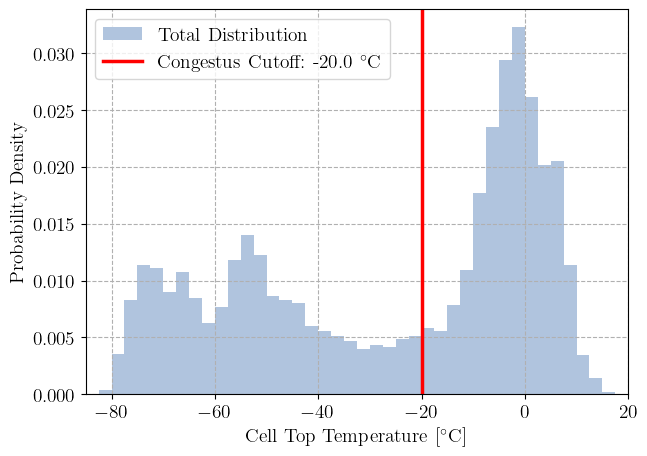

In [232]:
ctt_cutoff = -20.

# --- 4. Create the Diagnostic Plot ---
fig, ax = plt.subplots(figsize=(7, 5))
Fontsize = 14

# Plot the histogram of all data
ax.hist(macro_dict_1layer['ctt'], bins=np.arange(-85, 22.5, 2.5), density=True, color='lightsteelblue', label='Total Distribution')


# Plot the cutoff line
ax.axvline(ctt_cutoff, color='red', linestyle='-', lw=2.5, label=f'Congestus Cutoff: {ctt_cutoff:.1f} $^{{\circ}}$C')

# Formatting
ax.set_xlabel('Cell Top Temperature [$^{\\circ}$C]', fontsize=Fontsize)
ax.set_ylabel('Probability Density', fontsize=Fontsize)
#ax.set_title(f'CTT Distribution with {str(int(num_modes))}-Component GMM Fit', fontsize=Fontsize*1.2)
ax.tick_params(labelsize=Fontsize)
ax.grid(True, which='both', linestyle='--')
ax.legend(fontsize=Fontsize)
ax.set_xlim(-85, 20)
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
fig_name = 'fig_cell_top_temperature_pdf.png'
#plt.savefig(save_path+fig_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()



## Create congestus-only dictionaries

In [26]:
# --- Create the Final Congestus Dictionaries ---
print("\n--- Creating Final Congestus Dictionaries using CTT cutoff ---")
ctt_cutoff = -20.

# The mask is now simply where the CTT is warmer than the objective cutoff
final_congestus_mask = (macro_dict_1layer['ctt'] > ctt_cutoff)
congestus_indices = np.where(final_congestus_mask)[0]

print(f"Identified {len(congestus_indices)} congestus cells using CTT > {ctt_cutoff:.1f} C.")

# Filter all three dictionaries using these final indices
# (Assuming micro_dict_init and thermo_dict_init have been created as before)
macro_dict_cong = {key: val[congestus_indices] for key, val in macro_dict_1layer.items()}
micro_dict_cong = {key: val[congestus_indices, :] for key, val in micro_dict_init.items()}
thermo_dict_cong = {key: val[congestus_indices, :] for key, val in thermo_dict_init.items()}

print("\n`_cong` dictionaries created successfully.")


--- Creating Final Congestus Dictionaries using CTT cutoff ---
Identified 10127 congestus cells using CTT > -20.0 C.

`_cong` dictionaries created successfully.


In [27]:
micro_dict_cong.keys()

dict_keys(['mean_twc', 'mean_lwc', 'mean_clwc', 'mean_rwc', 'mean_iwc', 'mean_ciwc', 'mean_gwc', 'mean_swc', 'mean_nwa', 'mean_nc', 'mean_dbz', 'max_twc', 'max_lwc', 'max_clwc', 'max_rwc', 'max_iwc', 'max_ciwc', 'max_swc', 'max_gwc', 'max_nwa', 'max_nc', 'max_dbz', 'mean_qt', 'max_qt', 'mean_qc', 'max_qc', 'mean_qs', 'max_qs', 'mean_qi', 'max_qi', 'mean_qg', 'max_qg', 'mean_qr', 'max_qr', 'mean_qice', 'max_qice', 'mean_z'])

## Compute fraction of cells with ice at initiation

In [28]:
# --- 1. Define inputs and the common altitude grid ---
# Assume `micro_dict_cong` and `thermo_dict_cong` are loaded
thresh = 0.0

# Define the common altitude bins for compositing
if std:
    alt_bins = np.arange(0, 8500, 250) # 250m vertical bins
else:    
    alt_bins = np.arange(0, 12500, 250) # 250m vertical bins
alt_centers = (alt_bins[:-1] + alt_bins[1:]) / 2

# Get the full 2D arrays of data we need
z_profiles = thermo_dict_cong['mean_z']
ice_vars_to_process = ['mean_iwc', 'mean_ciwc', 'mean_swc', 'mean_gwc',
                       'max_iwc', 'max_ciwc', 'max_swc', 'max_gwc']

# Create an empty dictionary to store the results
binned_ice_fractions = {}

# --- 2. Correctly Calculate Binned Ice Fractions ---
print("Calculating binned ice fractions...")
for key in ice_vars_to_process:
    if key in micro_dict_cong:
        # Get the microphysical data for all cells
        micro_data = micro_dict_cong[key]
        
        # Initialize the output profile for this variable
        fraction_profile = np.full(len(alt_bins) - 1, np.nan)
        
        # Loop through each altitude bin
        for i in range(len(alt_bins) - 1):
            # Find all data points that fall within this altitude bin
            mask = (z_profiles >= alt_bins[i]) & (z_profiles < alt_bins[i+1])
            
            # Get the microphysical values from all cells in this altitude bin
            data_in_bin = micro_data[mask]
            
            # If there's enough data, calculate the fraction
            if len(data_in_bin) > 10: # A small threshold for robustness
                # The fraction is the mean of the boolean array (True=1, False=0)
                fraction_profile[i] = np.mean(data_in_bin > thresh)
        
        # Store the final binned profile
        binned_ice_fractions[key] = fraction_profile

print("Calculation of binned ice fractions complete.")

Calculating binned ice fractions...
Calculation of binned ice fractions complete.


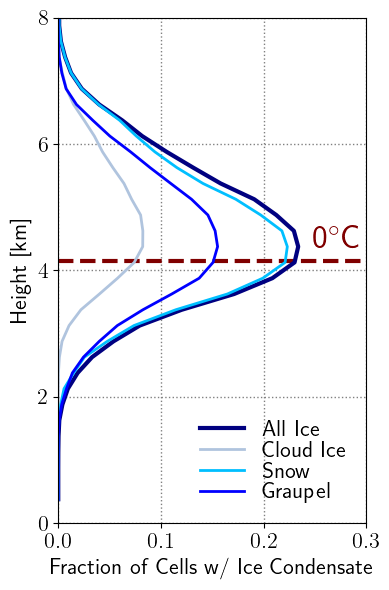

done


In [29]:
# --- 3. Plotting ---

# We need a mean temperature profile on the same altitude grid for the 0C line
# We can use the same binning method for temperature
mean_T_binned = np.full(len(alt_bins) - 1, np.nan)
temp_profiles = thermo_dict_cong['mean_T']
for i in range(len(alt_bins) - 1):
    mask = (z_profiles >= alt_bins[i]) & (z_profiles < alt_bins[i+1])
    temps_in_bin = temp_profiles[mask]
    if len(temps_in_bin) > 10:
        mean_T_binned[i] = np.mean(temps_in_bin)


# ---  Use interpolation to find the 0C level ---
# We need to find the altitude where the temperature crosses from positive to negative.
# First, filter out any NaNs from our binned profiles for clean interpolation.
valid_temp_mask = ~np.isnan(mean_T_binned)
valid_temps = mean_T_binned[valid_temp_mask]
valid_alts = alt_centers[valid_temp_mask]

# np.interp(x, xp, fp) finds the y-value for a given x-value.
# Here, we want to find the altitude (y) where the temperature (x) is 0.
# So we flip the arguments: x=0, xp=temperatures, fp=altitudes.
# We sort the temperatures to ensure they are monotonically increasing for interp.
sort_idx = np.argsort(valid_temps)
zero_c_alt_m = np.interp(0, valid_temps[sort_idx], valid_alts[sort_idx])



# --- Create the Figure ---
fig = plt.figure(figsize=(4, 6))
ax1 = fig.add_subplot(111)
Fontsize=16

# Figure setup
ax1.tick_params(labelsize=Fontsize)
ax1.grid(which='both', ls='dotted', c='grey', lw=1)
if std:
    ax1.set_ylim(0, 8)
    ax1.set_yticks(np.arange(0, 10, 2))
    ax1.set_xlim(0,0.3)
else:
    ax1.set_xlim(0, 0.35)
    ax1.set_ylim(0, 12)
    
ax1.set_ylabel('Height [km]', fontsize=Fontsize)
ax1.set_xlabel('Fraction of Cells w/ Ice Condensate', fontsize=Fontsize)

# --- Plot the 0C line using the new, correct altitude ---
ax1.axhline(zero_c_alt_m * 1.e-3, lw=3, c='maroon', ls='dashed')

# --- Plot the Corrected Profiles ---
# The y-axis is now the common altitude bin centers
ax1.plot(binned_ice_fractions['mean_iwc'], alt_centers * 1.e-3, c='navy', label='All Ice', lw=3)
ax1.plot(binned_ice_fractions['mean_ciwc'], alt_centers * 1.e-3, c='lightsteelblue', label='Cloud Ice', lw=2)
ax1.plot(binned_ice_fractions['mean_swc'], alt_centers * 1.e-3, c='deepskyblue', label='Snow', lw=2)
ax1.plot(binned_ice_fractions['mean_gwc'], alt_centers * 1.e-3, c='blue', label='Graupel', lw=2)

# Legend and text (unchanged)
ax1.legend(loc='lower right', framealpha=False, fontsize=Fontsize,labelspacing=0.05)
if std:
    ax1.text(ax1.get_xlim()[-1] - 0.052, zero_c_alt_m * 1.e-3 + 0.1, '0$^{\\circ}$C', fontsize=Fontsize*1.5, fontweight='bold', c='maroon', va='bottom')

else:
    ax1.text(ax1.get_xlim()[-1] - 0.06, zero_c_alt_m * 1.e-3 - 0.75, '0$^{\\circ}$C', fontsize=Fontsize*1.5, fontweight='bold', c='maroon')
if not std:
    plt.suptitle(rf'\textbf{{Defining Cell-top by $q_{{t}}$ $>$ 10$^{{-3}}$ g kg$^{{-1}}$}}',fontsize=Fontsize*0.9,y=0.95)
plt.tight_layout()
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
if std:
    outfile = save_path+'fig_frac_ice_profiles.png'
else:
    outfile = save_path+'fig_frac_ice_profiles_stricter_threshold.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')


In [30]:
micro_dict_cong.keys()

dict_keys(['mean_twc', 'mean_lwc', 'mean_clwc', 'mean_rwc', 'mean_iwc', 'mean_ciwc', 'mean_gwc', 'mean_swc', 'mean_nwa', 'mean_nc', 'mean_dbz', 'max_twc', 'max_lwc', 'max_clwc', 'max_rwc', 'max_iwc', 'max_ciwc', 'max_swc', 'max_gwc', 'max_nwa', 'max_nc', 'max_dbz', 'mean_qt', 'max_qt', 'mean_qc', 'max_qc', 'mean_qs', 'max_qs', 'mean_qi', 'max_qi', 'mean_qg', 'max_qg', 'mean_qr', 'max_qr', 'mean_qice', 'max_qice', 'mean_z'])

In [32]:
maxcol_max_iwc = np.max(micro_dict_cong['max_iwc'],axis=1)
dumid = np.where(maxcol_max_iwc > 1.e-6)[0]
print(len(dumid)/len(maxcol_max_iwc))

mean_dbz_cong = micro_dict_cong['mean_dbz'].copy()
max_dbz_cong = micro_dict_cong['max_dbz'].copy()
mean_z_cong = micro_dict_cong['mean_z'].copy()
has_ice_mask = np.max(micro_dict_cong['max_iwc'],axis=1) > 1.e-6

0.2393601263947862


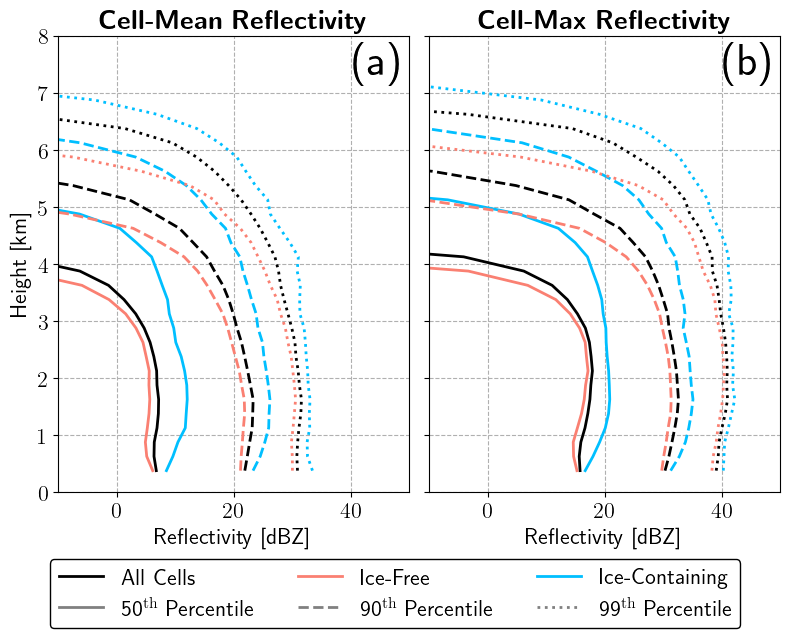

done


In [36]:
# --- 1. Setup and Data Preparation ---
# Assume you have these arrays ready from your analysis:
# mean_dbz_cong: (n_cong_cells, n_levels) - Mean dBZ profiles for all congestus cells
# max_dbz_cong:  (n_cong_cells, n_levels) - Max dBZ profiles for all congestus cells
# mean_z_cong:   (n_cong_cells, n_levels) - Corresponding altitude profiles
# has_ice_mask:  (n_cong_cells,) - Boolean mask, True for glaciating cells

ice_free_mask = ~has_ice_mask

# Define the common altitude bins for compositing
alt_bins = np.arange(0, 8250, 250) # Bins of 500m up to 8.5km
alt_centers = (alt_bins[:-1] + alt_bins[1:]) / 2

# Define the percentiles you want to calculate
percentiles_to_calc = [50, 90, 99]

# --- 2. Create a Helper Function for Calculation ---
def calculate_percentile_profiles(dbz_profiles, z_profiles, alt_bins, percentiles):
    """
    Calculates percentile profiles of dBZ by binning data into common altitude bins.
    
    Returns:
        A dictionary where keys are percentiles (e.g., 50) and values are 
        the corresponding dBZ profiles.
    """
    # Initialize a dictionary to store the results
    percentile_profiles = {p: np.full(len(alt_bins) - 1, np.nan) for p in percentiles}
    
    # Loop through each altitude bin
    for i in range(len(alt_bins) - 1):
        # Find all data points that fall within this altitude bin
        mask = (z_profiles >= alt_bins[i]) & (z_profiles < alt_bins[i+1])
        
        # Get the dBZ values from all cells that fall in this altitude bin
        dbz_in_bin = dbz_profiles[mask]
        
        # If there's enough data, calculate the percentiles
        if len(dbz_in_bin) > 10: # A small threshold to ensure robustness
            p_values = np.nanpercentile(dbz_in_bin, percentiles)
            for p_idx, p in enumerate(percentiles):
                percentile_profiles[p][i] = p_values[p_idx]
                
    return percentile_profiles

# --- 3. Perform Calculations for All Subsets ---

# Ice-Free Cells
p_profiles_mean_dbz_ice_free = calculate_percentile_profiles(mean_dbz_cong[ice_free_mask, :], mean_z_cong[ice_free_mask, :], alt_bins, percentiles_to_calc)
p_profiles_max_dbz_ice_free = calculate_percentile_profiles(max_dbz_cong[ice_free_mask, :], mean_z_cong[ice_free_mask, :], alt_bins, percentiles_to_calc)

# Glaciating Cells
p_profiles_mean_dbz_glaciating = calculate_percentile_profiles(mean_dbz_cong[has_ice_mask, :], mean_z_cong[has_ice_mask, :], alt_bins, percentiles_to_calc)
p_profiles_max_dbz_glaciating = calculate_percentile_profiles(max_dbz_cong[has_ice_mask, :], mean_z_cong[has_ice_mask, :], alt_bins, percentiles_to_calc)

# Glaciating Cells
p_profiles_mean_dbz_all = calculate_percentile_profiles(mean_dbz_cong[:, :], mean_z_cong[:, :], alt_bins, percentiles_to_calc)
p_profiles_max_dbz_all = calculate_percentile_profiles(max_dbz_cong[:, :], mean_z_cong[:, :], alt_bins, percentiles_to_calc)

# --- 4. Create the Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
Fontsize = 16

# Define styles for plotting
linestyles = {50: 'solid', 90: 'dashed', 99: 'dotted'}
labels = {50: '50$^{th}$ Percentile', 90: '90$^{th}$ Percentile', 99: '99$^{th}$ Percentile'}

# --- Panel 1: Mean dBZ ---
for p in percentiles_to_calc:

    # Plot All 
    ax1.plot(p_profiles_mean_dbz_all[p], alt_centers * 1e-3, 
             color='k', lw=2, linestyle=linestyles[p], 
             label=f'All Cells ({labels[p]})')
    
    # Plot Ice-Free 
    ax1.plot(p_profiles_mean_dbz_ice_free[p], alt_centers * 1e-3, 
             color='salmon', lw=2, linestyle=linestyles[p], 
             label=f'Ice-Free ({labels[p]})')
    # Plot Glaciating 
    ax1.plot(p_profiles_mean_dbz_glaciating[p], alt_centers * 1e-3, 
             color='deepskyblue', lw=2, linestyle=linestyles[p], 
             label=f'Glaciating ({labels[p]})')

# --- Panel 2: Max dBZ ---
for p in percentiles_to_calc:
    ax2.plot(p_profiles_max_dbz_all[p], alt_centers * 1e-3, 
             color='k', lw=2, linestyle=linestyles[p])
    ax2.plot(p_profiles_max_dbz_ice_free[p], alt_centers * 1e-3, 
             color='salmon', lw=2, linestyle=linestyles[p])
    ax2.plot(p_profiles_max_dbz_glaciating[p], alt_centers * 1e-3, 
             color='deepskyblue', lw=2, linestyle=linestyles[p])

# --- Formatting ---
ax1.set_title(r'\textbf{Cell-Mean Reflectivity}', fontsize=Fontsize*1.2)
ax2.set_title(r'\textbf{Cell-Max Reflectivity}', fontsize=Fontsize*1.2)

for ax in [ax1, ax2]:
    ax.set_xlabel('Reflectivity [dBZ]', fontsize=Fontsize)
    ax.grid(True, which='both', linestyle='--')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlim(-10, 50)
    ax.set_ylim(0, 8)

ax1.set_ylabel('Height [km]', fontsize=Fontsize)

# Create a single, clean legend
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='k', lw=2, label='All Cells'),
            Line2D([0], [0], color='gray', lw=2, ls='solid', label=r'50$^{\mathrm{th}}$ Percentile'),
            Line2D([0], [0], color='salmon', lw=2, label='Ice-Free'),
           Line2D([0], [0], color='gray', lw=2, ls='dashed', label=r'90$^{\mathrm{th}}$ Percentile'),
           Line2D([0], [0], color='deepskyblue', lw=2, label='Ice-Containing'),
           Line2D([0], [0], color='gray', lw=2, ls='dotted', label=r'99$^{\mathrm{th}}$ Percentile')]
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.125), ncol=3, fontsize=Fontsize,edgecolor='k',framealpha=True)

ax1.text(0.99,0.99,'(a)',ha='right',va='top',fontsize=Fontsize*2.,transform=ax1.transAxes)
ax2.text(0.99,0.99,'(b)',ha='right',va='top',fontsize=Fontsize*2.,transform=ax2.transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.tight_layout()
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+'fig_dbz_percentile_profiles_ice_vs_no-ice.png'
#plt.savefig(outfile,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')


# Calculate sub-cloud aerosol concentrations

# Calculate sub-cloud aerosol for all congestus cells ---

In [40]:
# Calculate sub-cloud aerosol for all congestus cells ---
max_qc_2d = micro_dict_cong['max_qc'].copy()
mean_nwa_2d = micro_dict_cong['mean_nwa'].copy()
height_2d = micro_dict_cong['mean_z'].copy()
temp_2d = thermo_dict_cong['mean_T'].copy()
print(np.shape(max_qc_2d))
print(np.shape(mean_nwa_2d))
print(np.shape(height_2d))
print(np.shape(temp_2d))
num_cells = len(macro_dict_cong['cth'])
print('num_cells:',num_cells) # same as the first dimension of 2D variables
sub_cloud_nwa_init = np.full(num_cells, np.nan, dtype=np.float32)
print(np.shape(sub_cloud_nwa_init))

# Parameters for the calculation
thresh_qc = 1.e-5      # Threshold for QCLOUD in kg/kg for identifying cloud base
sub_cloud_depth = 500.0 # Depth of layer below cloud base in meters
gap = 2
min_thick = 0


# Loop from 0 to num_cells-1. The index 'i' directly matches the rows
# in the _cong arrays. 
for i in range(num_cells):
    # Get the vertical profiles for this specific cell
    iheight = height_2d[i, :]
    itemp = temp_2d[i, :]
    iaero = mean_nwa_2d[i, :]
    iqc = max_qc_2d[i, :]
    
    # Find where the cloud exists (based on QCLOUD)
    idxcld_qc = np.array(np.where(iqc > thresh_qc)[0])

    # Only proceed if a liquid cloud base is actually found
    if len(idxcld_qc) > 0:
        # Use  existing helper function to find the cloud boundaries from QCLOUD
        # We only need the cloud base height (cb_qc) from the return values
        cb_qc, _, _, _, _, _ = calc_cloud_boundary(iheight, itemp, idxcld_qc, gap, min_thick)
        
        # If the function returned a valid cloud base
        if np.size(cb_qc) > 0:
            # Cloud base is the base of the lowest QCLOUD layer
            true_cloud_base_h = cb_qc[0]
            
            # Use the robust logic to calculate the mean aerosol in the layer below
            sub_cloud_top = true_cloud_base_h
            sub_cloud_bottom = true_cloud_base_h - sub_cloud_depth
            
            sub_cloud_indices = np.where(
                (iheight >= sub_cloud_bottom) & (iheight < sub_cloud_top)
            )[0]
            if len(sub_cloud_indices) > 0:
                sub_cloud_nwa_init[i] = np.nanmean(iaero[sub_cloud_indices])
            else:
                # Fallback: If no layer exists below (cloud base is at lowest level),
                # use the aerosol value AT the true cloud base.
                cbh_index = np.where(iheight == true_cloud_base_h)[0]
                if len(cbh_index) > 0:
                    sub_cloud_nwa_init[i] = iaero[cbh_index[0]]


# Check the number of valid values found
num_valid_nwa = np.count_nonzero(~np.isnan(sub_cloud_nwa_init))
print(f"\nCalculation finished. Found {num_valid_nwa} valid sub-cloud aerosol values.")
print(f"Percentage of NaNs: {100 * (1 - num_valid_nwa / num_cells):.1f}%")

# Now, add this correctly calculated array to your macro dictionary
macro_dict_cong['sub_cloud_nwa'] = sub_cloud_nwa_init

print("\n`macro_dict_1layer` now contains `sub_cloud_nwa`.")

(10127, 80)
(10127, 80)
(10127, 80)
(10127, 80)
num_cells: 10127
(10127,)

Calculation finished. Found 10125 valid sub-cloud aerosol values.
Percentage of NaNs: 0.0%

`macro_dict_1layer` now contains `sub_cloud_nwa`.


## Bin cells by aerosol loading

In [48]:
# Get the aerosol data to be used for binning.
aerosol_data = macro_dict_cong['sub_cloud_nwa']
valid_aerosol_mask = ~np.isnan(aerosol_data)
print(np.shape(np.where(valid_aerosol_mask == True)))
print(np.shape(np.where(valid_aerosol_mask == False)))
print(np.shape(macro_dict_cong['sub_cloud_nwa']))
# Filter all dictionaries to only include cells with valid aerosol data.
# This ensures all arrays have the same length and are perfectly aligned.
micro_dict_cong_valid = {key: val[valid_aerosol_mask, :] for key, val in micro_dict_cong.items()}
macro_dict_cong_valid = {key: val[valid_aerosol_mask] for key, val in macro_dict_cong.items()}
thermo_dict_cong_valid = {key: val[valid_aerosol_mask] for key, val in thermo_dict_cong.items()}
print(np.shape(macro_dict_cong_valid['sub_cloud_nwa']))

# Use clean aerosol data for binning
aerosol_data_filtered = macro_dict_cong_valid['sub_cloud_nwa']

(1, 10125)
(1, 2)
(10127,)
(10125,)


In [42]:
# --- 2. Define Bins and Assign Labels ---

# Define the edges of your aerosol bins
#bin_edges = [0, 500, 1000, 1500, 2000, np.inf]
#bin_edges = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, np.inf]
bin_edges = [0, 1000, 2000, 3000, 4000, np.inf]

# Define the labels for these bins
#bin_labels = ["0-500", "500-1000", "1000-1500", "1500-2000", "2000-2500","2500-3000","3000-3500","3500-4000", ">4000"]
bin_labels = ["0-1000", "1000-2000", "2000-3000", "3000-4000", ">4000"]

# Use pandas.cut to efficiently assign each cell to a bin
# `pd.cut` returns a series of labels, one for each cell.
bin_assignments = pd.cut(aerosol_data_filtered, bins=bin_edges, labels=bin_labels, right=False)

# --- Get the sample size for each bin ---
bin_counts = bin_assignments.value_counts().sort_index()

print("--- Binning Summary ---")
print("Number of cells in each aerosol bin:")
print(bin_counts)

--- Binning Summary ---
Number of cells in each aerosol bin:
0-1000        777
1000-2000    2772
2000-3000    2755
3000-4000    1710
>4000        2111
Name: count, dtype: int64


In [67]:
# --- (Your data preparation and aerosol binning sections are correct) ---
# ... you have `bin_assignments`, `bin_labels`, `bin_counts`
# ... you have `micro_dict_cong_valid` and `thermo_dict_cong_valid`

# --- NEW, CORRECTED: Calculate Binned Profiles on a Common Grid ---

# 1. Define the common vertical altitude grid we will bin everything onto.
alt_bins = np.arange(0, 8500, 250) # 200m vertical bins up to 8.6km
alt_centers = (alt_bins[:-1] + alt_bins[1:]) / 2 # The y-axis for our final plot

# 2. Create a new helper function based on your proven method
def calculate_binned_profile(micro_data, z_profiles, alt_bins, statistic='mean'):
    """
    Calculates a single composite profile (mean or median) by binning data 
    into a common altitude grid.
    """
    # Initialize the output profile
    binned_profile = np.full(len(alt_bins) - 1, np.nan)
    
    # Loop through each altitude bin
    for i in range(len(alt_bins) - 1):
        # Find all data points that fall within this altitude bin
        mask = (z_profiles >= alt_bins[i]) & (z_profiles < alt_bins[i+1])
        
        # Get the microphysical values from all cells that fall in this altitude bin
        data_in_bin = micro_data[mask]
        
        # If there's enough data, calculate the statistic
        if len(data_in_bin) > 10: # A small threshold for robustness
            if statistic == 'mean':
                binned_profile[i] = np.nanmean(data_in_bin)
            elif statistic == 'median':
                binned_profile[i] = np.nanmedian(data_in_bin)
                
    return binned_profile

# 3. Initialize final dictionaries and loop to calculate all profiles
var_names_to_process = ['mean_clwc', 'mean_rwc', 'mean_nc', 'mean_iwc']
binned_mean_profiles = {bin_label: {} for bin_label in bin_labels}
binned_med_profiles = {bin_label: {} for bin_label in bin_labels}

for bin_label in bin_labels:
    print(f"\nProcessing aerosol bin: {bin_label}...")
    cells_in_this_bin_mask = (bin_assignments == bin_label)
    
    # Get the altitude and microphysics profiles for ONLY the cells in this bin
    z_subset = thermo_dict_cong_valid['mean_z'][cells_in_this_bin_mask, :]
    
    for var_name in var_names_to_process:
        micro_subset = micro_dict_cong_valid[var_name][cells_in_this_bin_mask, :]
        # Calculate the mean and median profiles using the robust binning method
        binned_mean_profiles[bin_label][var_name] = calculate_binned_profile(micro_subset, z_subset, alt_bins, 'mean')
        binned_med_profiles[bin_label][var_name] = calculate_binned_profile(micro_subset, z_subset, alt_bins, 'median')

print("\n--- All Done! Binned profiles are correctly calculated. ---")




Processing aerosol bin: 0-1000...

Processing aerosol bin: 1000-2000...

Processing aerosol bin: 2000-3000...

Processing aerosol bin: 3000-4000...

Processing aerosol bin: >4000...

--- All Done! Binned profiles are correctly calculated. ---


In [78]:


# Your plotting code, with only the y-variable in the plot call changed.
nrows=1
ncols=5
#stat = 'mean'
stat = 'med'
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(10,3.5),constrained_layout=True)
Fontsize=12
for i,ax in enumerate(axs):
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_ylim(0,8)
    if i > 0:
        ax.tick_params(labelleft=False)
        
axs[0].set_ylabel('Height [km]',fontsize=Fontsize)

num_colors = len(bin_labels)
cmap = plt.colormaps['inferno']
colors = [cmap(i) for i in np.linspace(0, 0.9, num_colors)]

var_names = ['mean_clwc','mean_rwc','mean_nc','mean_iwc']
if stat == 'mean':
    var_labels = ['Avg. Mean CLWC [g m$^{-3}$]',\
                  'Avg. Mean RWC [g m$^{-3}$]',\
                  'Avg. Mean $N_{c}$ [cm$^{-3}$]',\
                  'Avg. Mean IWC [g m$^{-3}$]']
elif stat == 'med':
    var_labels = ['Med. Mean CLWC [g m$^{-3}$]',\
                  'Med. Mean RWC [g m$^{-3}$]',\
                  'Med. Mean $N_{c}$ [cm$^{-3}$]',\
                  'Med. Mean IWC [g m$^{-3}$]']    
lgnd_labels = ["0-1000", "1000-2000", "2000-3000", "3000-4000","$>$4000"] 

for ii in range(len(var_names)):
    for i, bin_label in enumerate(bin_labels):
        if stat == 'mean':
            dum_binned_profiles = binned_mean_profiles
        elif stat == 'med':
            dum_binned_profiles = binned_med_profiles
        
        if bin_label in dum_binned_profiles:
            sample_size = bin_counts.get(bin_label, 0)
            legend_label = f'$N_{{a}}$ = {lgnd_labels[i]} cm$^{{-3}}$\n(N = {sample_size})\n'
    
            profile_to_plot = dum_binned_profiles[bin_label][var_names[ii]]
            
            # --- THIS IS THE ONLY LINE THAT HAS CHANGED ---
            # Plot against the common altitude bin centers, not the overall mean_z
            axs[ii].plot(profile_to_plot, alt_centers * 1.e-3, 
                         label=legend_label, color=colors[i], lw=2)
            # --- END OF CHANGE ---

            axs[ii].set_xlabel(var_labels[ii],fontsize=Fontsize)
    
labs = [r'\textbf{(a)}',r'\textbf{(b)}',r'\textbf{(c)}',r'\textbf{(d)}']
dumi=0
for ax in axs[0:-1]:
    ax.text(0.99,0.98,labs[dumi],fontsize=Fontsize*2.,va='top',ha='right',transform=ax.transAxes)
    dumi+=1
    
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles, labels, fontsize=Fontsize, bbox_to_anchor=(0.9,0.94), 
                 loc='upper center', ncol=1,framealpha=False,labelspacing=0.025,columnspacing=0.1,edgecolor=None)

fig.delaxes(axs[-1])
plt.tight_layout()

if stat == 'med':
    axs[3].xaxis.set_major_formatter(mticker.FuncFormatter(my_formatter))

for ax in axs:
    ax.set_xlim(0)
    
save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+'fig_'+stat+'_cell_mean_micro_profiles_aero_dist.png'
plt.savefig(outfile,dpi=300)
#plt.show()
plt.close()
print('done')

/tmp/ipykernel_2186390/2181517286.py:66: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


done


## Consolidated figure of aerosol-binned profiles and ice fraction profiles that can be used for talks

/tmp/ipykernel_1504895/3212685687.py:79: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


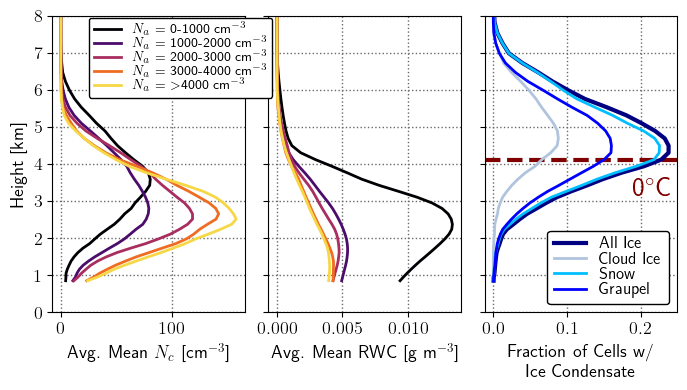

In [42]:
mean_z = np.mean(thermo_dict_cong['mean_z'], axis=0)

nrows=1
ncols=3

fig, axs = plt.subplots(nrows=nrows,ncols=ncols,figsize=(7,4),constrained_layout=True)
Fontsize=13
for i,ax in enumerate(axs):
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both',lw=1,c='dimgrey',ls='dotted')
    ax.set_ylim(0,8)
    if (i > 0):
        ax.tick_params(labelleft=False)
        
axs[0].set_ylabel('Height [km]',fontsize=Fontsize)



num_colors = len(bin_labels)
cmap = plt.colormaps['inferno']
colors = [cmap(i) for i in np.linspace(0, 0.9, num_colors)]

var_names = ['mean_nc','mean_rwc']
var_labels = ['Avg. Mean $N_{c}$ [cm$^{-3}$]',\
              'Avg. Mean RWC [g m$^{-3}$]']
lgnd_labels = ["0-1000", "1000-2000", "2000-3000", "3000-4000", "$>$4000"] 

for ii in range(len(var_names)):
    # Loop through each bin label
    for i, bin_label in enumerate(bin_labels):
        # Check if the bin has data before trying to plot
        if bin_label in binned_mean_profiles:
            
            # --- THIS IS THE NEW PART ---
            # Get the sample size (N) for the current bin from our `bin_counts` series
            sample_size = bin_counts.get(bin_label, 0)
            
            # Create a dynamic legend label that includes the sample size
            legend_label = f'$N_{{a}}$ = {lgnd_labels[i]} cm$^{{-3}}$'
            # --- END OF NEW PART ---
    
            # Access the specific profile you want to plot
            profile_to_plot = binned_mean_profiles[bin_label][var_names[ii]]
            
            # Plot using the new legend label
            axs[ii].plot(profile_to_plot, mean_z * 1.e-3, 
                    label=legend_label, color=colors[i], lw=2)
            axs[ii].set_xlabel(var_labels[ii],fontsize=Fontsize)
    
    
handles, labels = axs[0].get_legend_handles_labels()
#lgd = fig.legend(handles, labels, fontsize=Fontsize*0.8, bbox_to_anchor=(0.89,0.9), 
lgd = fig.legend(handles, labels, fontsize=Fontsize*0.75, bbox_to_anchor=(0.265,0.96), 
                 loc='upper center', ncol=1,framealpha=True,labelspacing=0.05,columnspacing=0.1,edgecolor='k')

ax = axs[-1]
ax.set_xlabel('Fraction of Cells w/\nIce Condensate', fontsize=Fontsize)
ax.axhline(mean_z[nearest_id] * 1.e-3, lw=3, c='maroon', ls='dashed')

# --- Updated plotting calls ---
# IWC
ax.plot(ice_fractions['mean_iwc'], mean_z * 1.e-3, c='navy', label='All Ice', lw=3)
# CIWC
ax.plot(ice_fractions['mean_ciwc'], mean_z * 1.e-3, c='lightsteelblue', label='Cloud Ice', lw=2)
# SWC
ax.plot(ice_fractions['mean_swc'], mean_z * 1.e-3, c='deepskyblue', label='Snow', lw=2)
# GWC
ax.plot(ice_fractions['mean_gwc'], mean_z * 1.e-3, c='blue', label='Graupel', lw=2)

# Legend and text (unchanged)
ax.legend(loc='lower right', framealpha=True, fontsize=Fontsize*0.9,labelspacing=0.05,edgecolor='k')
ax.text(ax1.get_xlim()[-1] - 0.11, mean_z[nearest_id] * 1.e-3 - 1., '0$^{\\circ}$C', fontsize=Fontsize*1.5, fontweight='bold', c='maroon')

#plt.subplots_adjust(hspace=0.4,wspace=0.2)
plt.tight_layout()

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+'fig_cell_max_micro_profiles_aero_dist.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()